In [1]:
import pickle
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def get_mismatch_array(filename, mismatch_type):
    """
    Load a specific mismatch array from the saved pickle.

    Parameters
    ----------
    filename : str
        Path to pickle file.

    mismatch_type : str
        One of:

        "RP"
        "IMR_full_22"
        "IMR_full_2m"
        "IMR_full_3m"
        "IMR_full_all"
        "IMR_cut_22"
        "IMR_cut_2m"
        "IMR_cut_3m"
        "IMR_cut_all"

    Returns
    -------
    np.ndarray
        1D array of mismatches with failed entries removed.
    """

    with open(filename, "rb") as f:
        data = pickle.load(f)

    if mismatch_type == "RP":
        arr = data["Mismatch RP vs NP RegPre"]

    elif mismatch_type.startswith("IMR_full"):
        mode_map = {
            "IMR_full_22": "2, 2",
            "IMR_full_2m": "2, m",
            "IMR_full_3m": "3, m",
            "IMR_full_all": "all",
        }

        mode = mode_map[mismatch_type]

        arr = [
            d[mode]
            for d in data["Mismatch RP vs NP IMR full"]
            if d is not None
        ]

    elif mismatch_type.startswith("IMR_cut"):
        mode_map = {
            "IMR_cut_22": "2, 2",
            "IMR_cut_2m": "2, m",
            "IMR_cut_3m": "3, m",
            "IMR_cut_all": "all",
        }

        mode = mode_map[mismatch_type]

        arr = [
            d[mode]
            for d in data["Mismatch RP vs NP IMR cut"]
            if d is not None
        ]

    else:
        raise ValueError(f"Unknown mismatch type: {mismatch_type}")

    return np.asarray([x for x in arr if x is not None])

In [2]:
def get_cos_iJN(rp_params):
    """
    Compute cos(iota_JN) — the inclination of J relative to the line of sight N —
    from the sky/orientation angles stored in rp_params.

    The unit vector of J in Cartesian coordinates:
        J = (sin(theta_J)*cos(phi_J), sin(theta_J)*sin(phi_J), cos(theta_J))

    The unit vector of N (line of sight) in Cartesian coordinates:
        N = (sin(theta_S)*cos(phi_S), sin(theta_S)*sin(phi_S), cos(theta_S))

    cos(iota_JN) = J . N
    """
    theta_J = rp_params["theta_J"]
    phi_J   = rp_params["phi_J"]
    theta_S = rp_params["theta_S"]
    phi_S   = rp_params["phi_S"]

    return np.sin(theta_J) * np.sin(theta_S) * np.cos(phi_J - phi_S) + np.cos(theta_J) * np.cos(theta_S)


def get_mismatch_and_cos_iJN(filename, mismatch_type):
    """
    Load a specific mismatch array AND the matching cos(iota_JN) values
    from the saved pickle, dropping any entries where the mismatch is None.

    Parameters
    ----------
    filename : str
        Path to pickle file.
    mismatch_type : str
        One of:
            "RP"
            "IMR_full_22", "IMR_full_2m", "IMR_full_3m", "IMR_full_all"
            "IMR_cut_22",  "IMR_cut_2m",  "IMR_cut_3m",  "IMR_cut_all"

    Returns
    -------
    mismatches : np.ndarray   shape (M,)
    cos_iJN    : np.ndarray   shape (M,)
        Both arrays have the same length M (failed entries removed).
    """
    with open(filename, "rb") as f:
        data = pickle.load(f)

    parameters = data["Parameters"]          # list of param_package dicts

    # ------------------------------------------------------------------ #
    # Build a list of (mismatch_value, rp_params) pairs, one per binary   #
    # ------------------------------------------------------------------ #
    if mismatch_type == "RP":
        raw = data["Mismatch RP vs NP RegPre"]
        pairs = [(m, p["rp_params"]) for m, p in zip(raw, parameters)]

    elif mismatch_type.startswith("IMR_full"):
        mode_map = {
            "IMR_full_22":  "2, 2",
            "IMR_full_2m":  "2, m",
            "IMR_full_3m":  "3, m",
            "IMR_full_all": "all",
        }
        mode = mode_map[mismatch_type]
        raw  = data["Mismatch RP vs NP IMR full"]
        pairs = [
            (d[mode] if d is not None else None, p["rp_params"])
            for d, p in zip(raw, parameters)
        ]

    elif mismatch_type.startswith("IMR_cut"):
        mode_map = {
            "IMR_cut_22":  "2, 2",
            "IMR_cut_2m":  "2, m",
            "IMR_cut_3m":  "3, m",
            "IMR_cut_all": "all",
        }
        mode = mode_map[mismatch_type]
        raw  = data["Mismatch RP vs NP IMR cut"]
        pairs = [
            (d[mode] if d is not None else None, p["rp_params"])
            for d, p in zip(raw, parameters)
        ]

    else:
        raise ValueError(f"Unknown mismatch type: {mismatch_type}")

    # ------------------------------------------------------------------ #
    # Filter out None mismatches and compute cos(iota_JN) for survivors  #
    # ------------------------------------------------------------------ #
    mismatches = []
    cos_iJN    = []

    for mismatch, rp_params in pairs:
        if mismatch is None:
            continue
        mismatches.append(mismatch)
        cos_iJN.append(get_cos_iJN(rp_params))

    return np.asarray(mismatches), np.asarray(cos_iJN)


def get_RP_params_mismatches(filename, mismatch_type):
    """
    Load the RP parameters for all binaries where the specified mismatch is not None.

    Parameters
    ----------
    filename : str
        Path to pickle file.
    mismatch_type : str
        One of:
            "RP"
            "IMR_full_22", "IMR_full_2m", "IMR_full_3m", "IMR_full_all"
            "IMR_cut_22",  "IMR_cut_2m",  "IMR_cut_3m",  "IMR_cut_all"

    Returns
    -------
    rp_params_list : list of dicts
        List of rp_params dicts for binaries where the specified mismatch is not None.
    """
    with open(filename, "rb") as f:
        data = pickle.load(f)

    parameters = data["Parameters"]          # list of param_package dicts

    # ------------------------------------------------------------------ #
    # Build a list of (mismatch_value, rp_params, additional_params) pairs, one per binary  #
    # ------------------------------------------------------------------ #
    if mismatch_type == "RP":
        raw = data["Mismatch RP vs NP RegPre"]
        pairs = [(m, p["rp_params"], p["theta_1"], p["theta_2"], p["phi_1"], p["phi_2"]) for m, p in zip(raw, parameters)]

    elif mismatch_type.startswith("IMR_full"):
        mode_map = {
            "IMR_full_22":  "2, 2",
            "IMR_full_2m":  "2, m",
            "IMR_full_3m":  "3, m",
            "IMR_full_all": "all",
        }
        mode = mode_map[mismatch_type]
        raw  = data["Mismatch RP vs NP IMR full"]
        pairs = [
            (d[mode] if d is not None else None, p["rp_params"], p["theta_1"], p["theta_2"], p["phi_1"], p["phi_2"])
            for d, p in zip(raw, parameters)
        ]

    elif mismatch_type.startswith("IMR_cut"):
        mode_map = {
            "IMR_cut_22":  "2, 2",
            "IMR_cut_2m":  "2, m",
            "IMR_cut_3m":  "3, m",
            "IMR_cut_all": "all",
        }
        mode = mode_map[mismatch_type]
        raw  = data["Mismatch RP vs NP IMR cut"]
        pairs = [
            (d[mode] if d is not None else None, p["rp_params"], p["theta_1"], p["theta_2"], p["phi_1"], p["phi_2"])
            for d, p in zip(raw, parameters)
        ]
        
    else:
        raise ValueError(f"Unknown mismatch type: {mismatch_type}")
    
    # ------------------------------------------------------------------ #
    # Filter out None mismatches and collect rp_params for survivors     #
    # ------------------------------------------------------------------ #
    rp_params_list = [rp_params for mismatch, rp_params, theta_1, theta_2, phi_1, phi_2 in pairs if mismatch is not None]
    theta_1_list = [theta_1 for mismatch, rp_params, theta_1, theta_2, phi_1, phi_2 in pairs if mismatch is not None]
    theta_2_list = [theta_2 for mismatch, rp_params, theta_1, theta_2, phi_1, phi_2 in pairs if mismatch is not None]
    phi_1_list = [phi_1 for mismatch, rp_params, theta_1, theta_2, phi_1, phi_2 in pairs if mismatch is not None]
    phi_2_list = [phi_2 for mismatch, rp_params, theta_1, theta_2, phi_1, phi_2 in pairs if mismatch is not None]
    
    return rp_params_list, theta_1_list, theta_2_list, phi_1_list, phi_2_list

In [3]:
filename = "saved_data/IMRPhenomXPHM/Comparison_RP_IMRPhenomXPHM_mcz20_q10_chi1_10_chi2_10_z3.pkl"

mismatch_rp_m20_q1_chi1_1_chi2_1_z03, cos_iJN_rp_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "RP")

mismatch_imr22_m20_q1_chi1_1_chi2_1_z03_full, cos_iJN_imr22_full_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_full_22")
rp_params_q1_chi1_1_chi2_1_z03_full, theta_1_q1_chi1_1_chi2_1_z03_full, theta_2_q1_chi1_1_chi2_1_z03_full, phi_1_q1_chi1_1_chi2_1_z03_full, phi_2_q1_chi1_1_chi2_1_z03_full = get_RP_params_mismatches(filename, "IMR_full_22")
mismatch_imr2m_m20_q1_chi1_1_chi2_1_z03_full, cos_iJN_imr2m_full_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_full_2m")
mismatch_imr3m_m20_q1_chi1_1_chi2_1_z03_full, cos_iJN_imr3m_full_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_full_3m")
mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_full, cos_iJN_imrall_full_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_full_all")

mismatch_imr22_m20_q1_chi1_1_chi2_1_z03_cut, cos_iJN_imr22_cut_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_cut_22")
mismatch_imr2m_m20_q1_chi1_1_chi2_1_z03_cut, cos_iJN_imr2m_cut_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_cut_2m")
mismatch_imr3m_m20_q1_chi1_1_chi2_1_z03_cut, cos_iJN_imr3m_cut_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_cut_3m")
mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_cut, cos_iJN_imrall_cut_chi1_1_chi2_1 = get_mismatch_and_cos_iJN(filename, "IMR_cut_all")

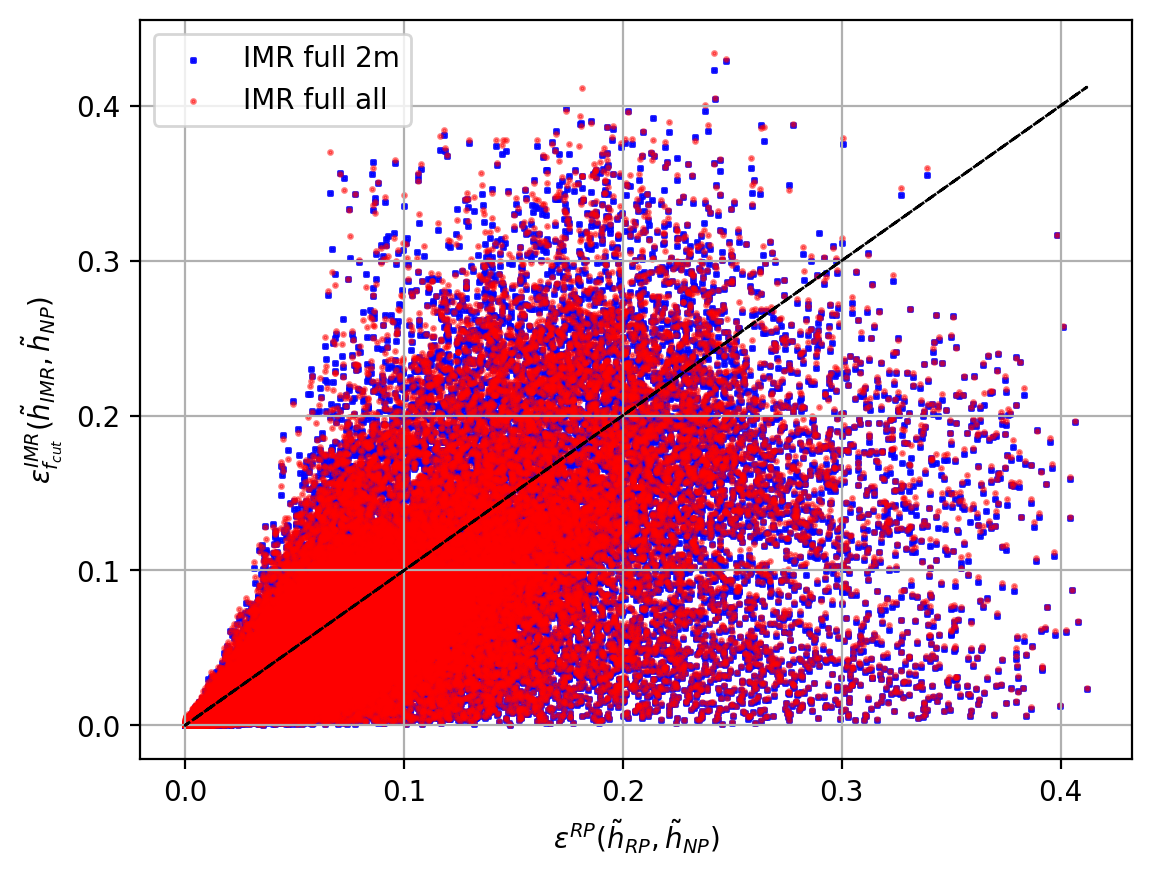

In [4]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200

plt.plot(mismatch_rp_m20_q1_chi1_1_chi2_1_z03, mismatch_rp_m20_q1_chi1_1_chi2_1_z03, color="black", linestyle="--", linewidth=1)
#plt.scatter(mismatch_rp_m20_q1_chi1_1_chi2_1_z03, mismatch_imr22_m20_q1_chi1_1_chi2_1_z03_cut, label="IMR full 22", color="blue", marker="o", alpha=0.7)
plt.scatter(mismatch_rp_m20_q1_chi1_1_chi2_1_z03, mismatch_imr2m_m20_q1_chi1_1_chi2_1_z03_cut, s = 2, label="IMR full 2m", color="blue", marker="s", alpha=0.9)
#plt.scatter(mismatch_rp_m20_q1_chi1_1_chi2_1_z03, mismatch_imr3m_m20_q1_chi1_1_chi2_1_z03_cut, label="IMR full 3m", color="green", marker="^", alpha=0.7)
plt.scatter(mismatch_rp_m20_q1_chi1_1_chi2_1_z03, mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_cut, s = 2, label="IMR full all", color="red", marker="o", alpha=0.5)

plt.xlabel(r"$\epsilon^{RP}(\tilde{h}_{RP}, \tilde{h}_{NP})$")
plt.ylabel(r"$\epsilon^{IMR}_{f_{cut}}(\tilde{h}_{IMR}, \tilde{h}_{NP})$")
#plt.title("Mismatch Comparison for mcz=20, q=1, chi1=1, chi2=1, z=0.3")
plt.legend()
plt.grid(True)
plt.show()


Distribution of mismatch differences (IMR fcut all): 5th percentile: -0.074, 50th percentile: -0.004, 95th percentile: 0.033
Distribution of mismatch differences (IMR fcut 3m): 5th percentile: -0.075, 50th percentile: -0.004, 95th percentile: 0.031
Distribution of mismatch differences (IMR fcut 2m): 5th percentile: -0.075, 50th percentile: -0.004, 95th percentile: 0.030
Distribution of mismatch differences (IMR fcut 22): 5th percentile: -0.185, 50th percentile: -0.028, 95th percentile: -0.001


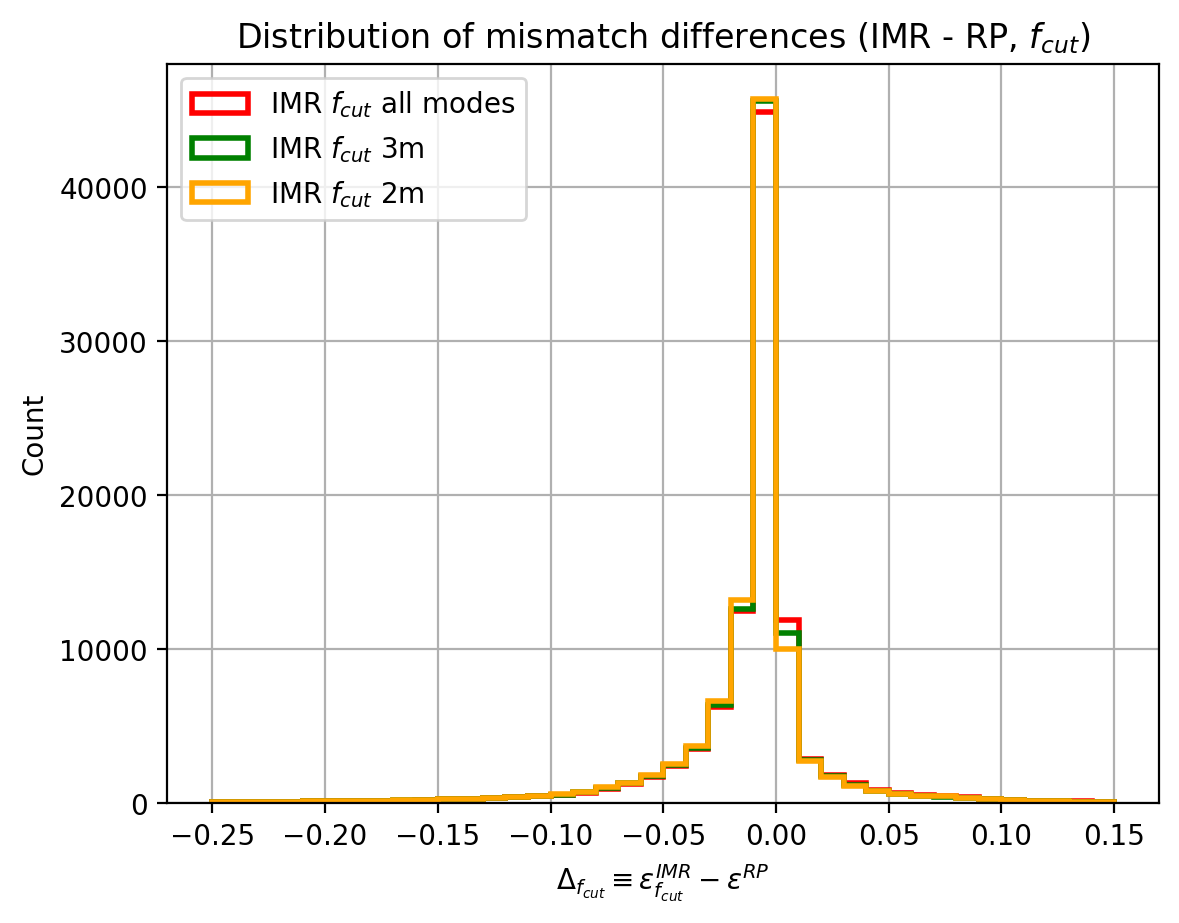

In [5]:
delta_22_cut = (
    np.array(mismatch_imr22_m20_q1_chi1_1_chi2_1_z03_cut)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_22_full = (
    np.array(mismatch_imr22_m20_q1_chi1_1_chi2_1_z03_full)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_2m_cut = (
    np.array(mismatch_imr2m_m20_q1_chi1_1_chi2_1_z03_cut)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_2m_full = (
    np.array(mismatch_imr2m_m20_q1_chi1_1_chi2_1_z03_full)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_3m_cut = (
    np.array(mismatch_imr3m_m20_q1_chi1_1_chi2_1_z03_cut)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_3m_full = (
    np.array(mismatch_imr3m_m20_q1_chi1_1_chi2_1_z03_full)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_all_cut = (
    np.array(mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_cut)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)
delta_all_full = (
    np.array(mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_full)
    - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)
)

bins_delta_arr = np.linspace(-0.25, 0.15, 41)

plt.hist(delta_all_cut, bins=bins_delta_arr, alpha=1, color="red", label=r"IMR $f_{cut}$ all modes", facecolor="none", edgecolor="red", linewidth=2, histtype="step")
plt.hist(delta_3m_cut, bins=bins_delta_arr, alpha=1, color="green", label=r"IMR $f_{cut}$ 3m", facecolor="none", edgecolor="green", linewidth=2, histtype="step")
plt.hist(delta_2m_cut, bins=bins_delta_arr, alpha=1, color="orange", label=r"IMR $f_{cut}$ 2m", facecolor="none", edgecolor="orange", linewidth=2, histtype="step")
#plt.hist(delta_22_cut, bins=bins_delta_arr, alpha=0.2, color="blue", label=r"IMR $f_{cut}$ 22", facecolor="none", edgecolor="blue", linewidth=2, histtype="step")

plt.legend(loc="upper left")

print(f"Distribution of mismatch differences (IMR fcut all): 5th percentile: {np.percentile(delta_all_cut, 5):.3f}, 50th percentile: {np.percentile(delta_all_cut, 50):.3f}, 95th percentile: {np.percentile(delta_all_cut, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 3m): 5th percentile: {np.percentile(delta_3m_cut, 5):.3f}, 50th percentile: {np.percentile(delta_3m_cut, 50):.3f}, 95th percentile: {np.percentile(delta_3m_cut, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 2m): 5th percentile: {np.percentile(delta_2m_cut, 5):.3f}, 50th percentile: {np.percentile(delta_2m_cut, 50):.3f}, 95th percentile: {np.percentile(delta_2m_cut, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 22): 5th percentile: {np.percentile(delta_22_cut, 5):.3f}, 50th percentile: {np.percentile(delta_22_cut, 50):.3f}, 95th percentile: {np.percentile(delta_22_cut, 95):.3f}")

plt.xlabel(r"$\Delta_{f_{cut}} \equiv \epsilon^{IMR}_{f_{cut}} - \epsilon^{RP}$")
plt.ylabel("Count")
plt.title(r"Distribution of mismatch differences (IMR - RP, $f_{cut}$)")
plt.grid(True)
plt.show()

Distribution of mismatch differences (IMR fcut all): 5th percentile: -0.074, 50th percentile: -0.004, 95th percentile: 0.033
Distribution of mismatch differences (IMR fcut 3m): 5th percentile: -0.075, 50th percentile: -0.004, 95th percentile: 0.031
Distribution of mismatch differences (IMR fcut 2m): 5th percentile: -0.075, 50th percentile: -0.004, 95th percentile: 0.030
Distribution of mismatch differences (IMR fcut 22): 5th percentile: -0.185, 50th percentile: -0.028, 95th percentile: -0.001


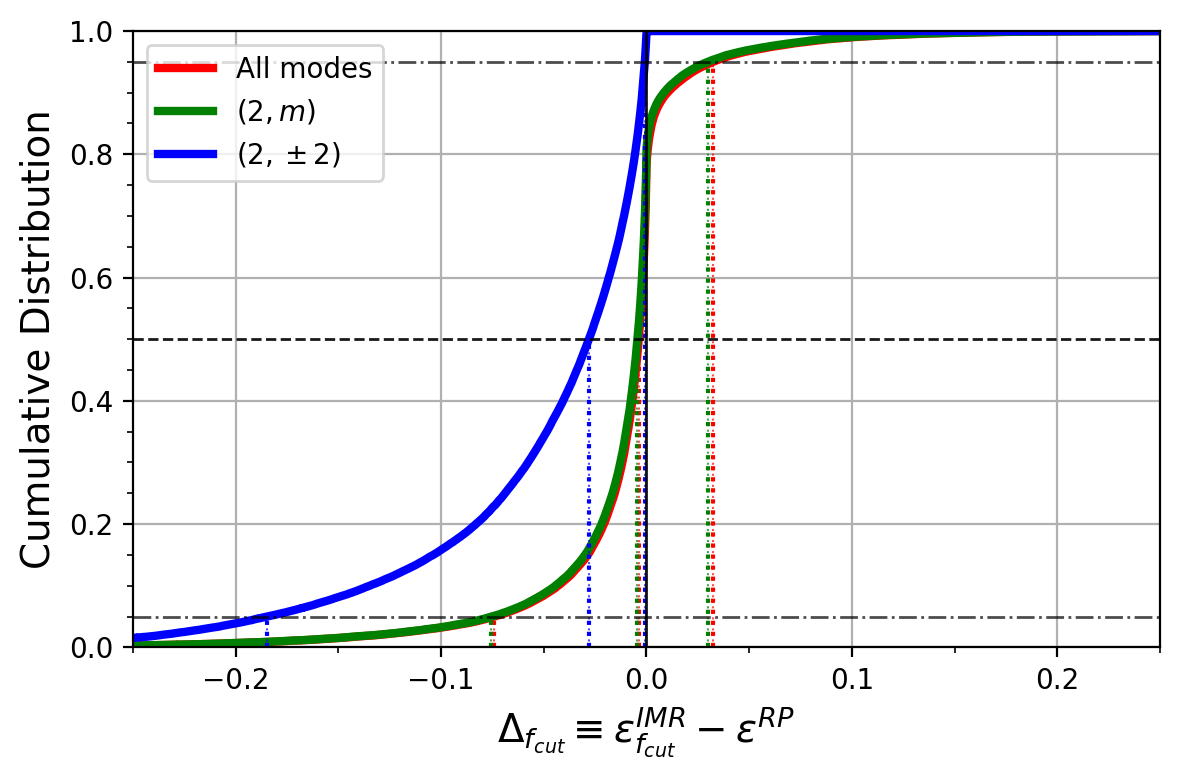

In [6]:
plt.figure(figsize=(6, 4), dpi=200)

def plot_cdf(ax, data, color, label, linestyle="-"):
    sorted_data = np.sort(data)
    Total_count = len(data)
    
    PDF_values = []
    iter_data = 0
    for d in data:
        PDF_values.append(iter_data / Total_count)
        iter_data += 1
    cdf = np.array(PDF_values)
    ax.plot(sorted_data, cdf, color=color, linewidth=3, label=label, linestyle=linestyle)
    for p in [5, 50, 95]:
        x_val = np.percentile(data, p)
        y_val = p / 100
        ax.vlines(x_val, ymin=0, ymax=y_val, color=color, linestyle=":", linewidth=1.5, alpha=1)
        x_val = np.percentile(data, p)
        y_val = p / 100
        ax.vlines(x_val, ymin=0, ymax=y_val, color=color, linestyle=":", linewidth=0.75, alpha=0.7)

plot_cdf(plt.gca(), delta_all_cut, color="red",    label=r"All modes")
#plot_cdf(delta_3m_cut,  color="orange",  label=r"IMR $f_{cut}$ 3m")
plot_cdf(plt.gca(), delta_2m_cut,  color="green", label=r"$(2, m)$")
plot_cdf(plt.gca(), delta_22_cut, color="blue",  label=r"$(2, \pm 2)$")

plt.axvline(0, color="k", linestyle="-", linewidth=1, alpha=0.9)
#plt.axvline(0.01, color="black", linestyle="-", linewidth=1, alpha=0.7)
#plt.axvline(-0.01, color="black", linestyle="-", linewidth=1, alpha=0.7)

plt.axhline(0.5, color="k", linestyle="--", linewidth=1, alpha=0.9)

plt.axhline(0.05, color="k", linestyle="-.", linewidth=1, alpha=0.7)
plt.axhline(0.95, color="k", linestyle="-.", linewidth=1, alpha=0.7)

plt.legend(loc="upper left")

print(f"Distribution of mismatch differences (IMR fcut all): 5th percentile: {np.percentile(delta_all_cut, 5):.3f}, 50th percentile: {np.percentile(delta_all_cut, 50):.3f}, 95th percentile: {np.percentile(delta_all_cut, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 3m): 5th percentile: {np.percentile(delta_3m_cut, 5):.3f}, 50th percentile: {np.percentile(delta_3m_cut, 50):.3f}, 95th percentile: {np.percentile(delta_3m_cut, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 2m): 5th percentile: {np.percentile(delta_2m_cut, 5):.3f}, 50th percentile: {np.percentile(delta_2m_cut, 50):.3f}, 95th percentile: {np.percentile(delta_2m_cut, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 22): 5th percentile: {np.percentile(delta_22_cut, 5):.3f}, 50th percentile: {np.percentile(delta_22_cut, 50):.3f}, 95th percentile: {np.percentile(delta_22_cut, 95):.3f}")

plt.xlabel(r"$\Delta_{f_{cut}} \equiv \epsilon^{IMR}_{f_{cut}} - \epsilon^{RP}$", fontsize=14)
plt.ylabel(r"Cumulative Distribution", fontsize=14)
#plt.title(r"CDF of mismatch differences (IMR - RP, $f_{cut}$)")
plt.xlim(-0.25, 0.25)
plt.ylim(0, 1)
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.05))
plt.tight_layout()

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_CDF_fcut_m20_q1_s11_N105_all_2m_22.pdf', format='pdf', bbox_inches = 'tight')

Distribution of mismatch differences (IMR fcut all): 5th percentile: -0.099, 50th percentile: -0.001, 95th percentile: 0.160
Distribution of mismatch differences (IMR fcut 3m): 5th percentile: -0.101, 50th percentile: -0.001, 95th percentile: 0.157
Distribution of mismatch differences (IMR fcut 2m): 5th percentile: -0.103, 50th percentile: -0.002, 95th percentile: 0.155
Distribution of mismatch differences (IMR fcut 22): 5th percentile: -0.160, 50th percentile: -0.014, 95th percentile: 0.073


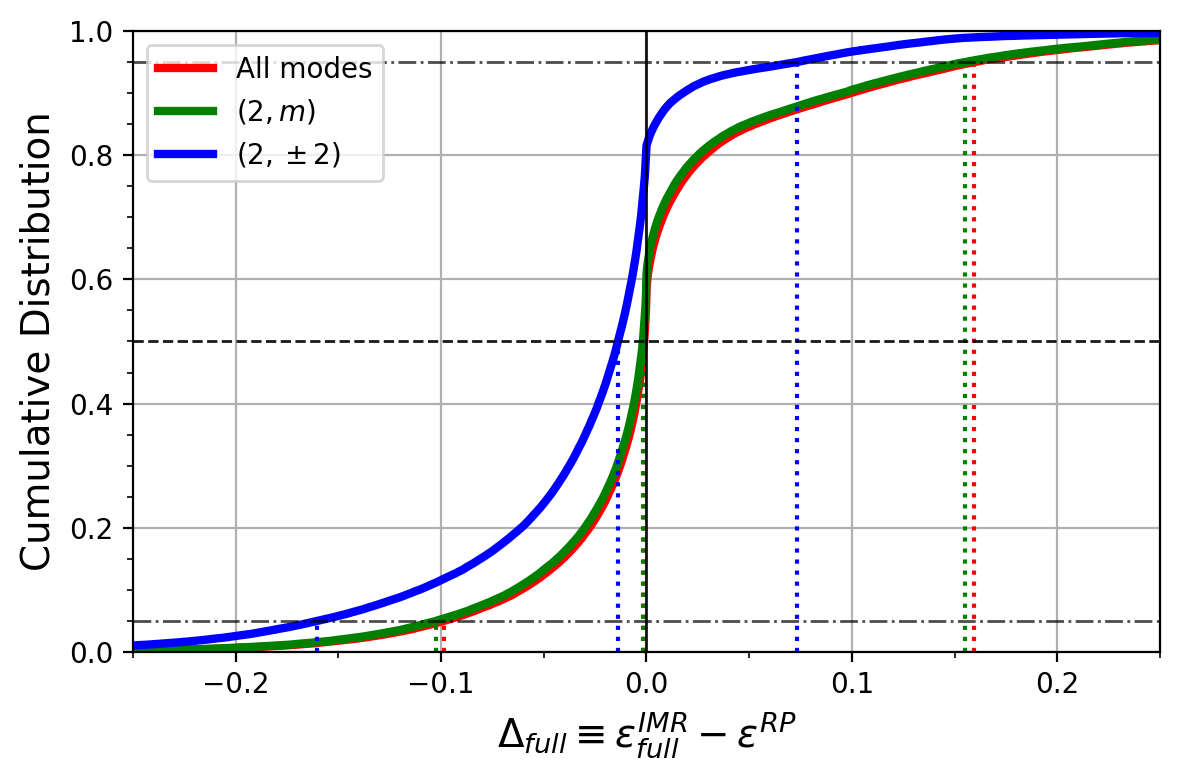

In [7]:
plt.figure(figsize=(6, 4), dpi=200)

def plot_cdf(ax, data, color, label, linestyle="-"):
    sorted_data = np.sort(data)
    Total_count = len(data)
    
    PDF_values = []
    iter_data = 0
    for d in data:
        PDF_values.append(iter_data / Total_count)
        iter_data += 1
    cdf = np.array(PDF_values)
    ax.plot(sorted_data, cdf, color=color, linewidth=3, label=label, linestyle=linestyle)
    for p in [5, 50, 95]:
        x_val = np.percentile(data, p)
        y_val = p / 100
        ax.vlines(x_val, ymin=0, ymax=y_val, color=color, linestyle=":", linewidth=1.5, alpha=1)

plot_cdf(plt.gca(), delta_all_full, color="red",    label=r"All modes")
#plot_cdf(plt.gca(), delta_3m_full,  color="orange",  label=r"IMR $f_{cut}$ 3m")
plot_cdf(plt.gca(), delta_2m_full,  color="green", label=r"$(2, m)$")
plot_cdf(plt.gca(), delta_22_full, color="blue",  label=r"$(2, \pm 2)$")

plt.axvline(0, color="k", linestyle="-", linewidth=1, alpha=0.9)
#plt.axvline(0.01, color="black", linestyle="-", linewidth=1, alpha=0.7)
#plt.axvline(-0.01, color="black", linestyle="-", linewidth=1, alpha=0.7)

plt.axhline(0.5, color="k", linestyle="--", linewidth=1, alpha=0.9)

plt.axhline(0.05, color="k", linestyle="-.", linewidth=1, alpha=0.7)
plt.axhline(0.95, color="k", linestyle="-.", linewidth=1, alpha=0.7)

plt.legend(loc="upper left")

print(f"Distribution of mismatch differences (IMR fcut all): 5th percentile: {np.percentile(delta_all_full, 5):.3f}, 50th percentile: {np.percentile(delta_all_full, 50):.3f}, 95th percentile: {np.percentile(delta_all_full, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 3m): 5th percentile: {np.percentile(delta_3m_full, 5):.3f}, 50th percentile: {np.percentile(delta_3m_full, 50):.3f}, 95th percentile: {np.percentile(delta_3m_full, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 2m): 5th percentile: {np.percentile(delta_2m_full, 5):.3f}, 50th percentile: {np.percentile(delta_2m_full, 50):.3f}, 95th percentile: {np.percentile(delta_2m_full, 95):.3f}")
print(f"Distribution of mismatch differences (IMR fcut 22): 5th percentile: {np.percentile(delta_22_full, 5):.3f}, 50th percentile: {np.percentile(delta_22_full, 50):.3f}, 95th percentile: {np.percentile(delta_22_full, 95):.3f}")

plt.xlabel(r"$\Delta_{full} \equiv \epsilon^{IMR}_{full} - \epsilon^{RP}$", fontsize=14)
plt.ylabel(r"Cumulative Distribution", fontsize=14)
#plt.title(r"CDF of mismatch differences (IMR - RP, $f_{cut}$)")
plt.xlim(-0.25, 0.25)
plt.ylim(0, 1)
plt.grid(True)
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.05))
plt.tight_layout()

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_CDF_full_m20_q1_s11_N105_all_2m_22.pdf', format='pdf', bbox_inches = 'tight')

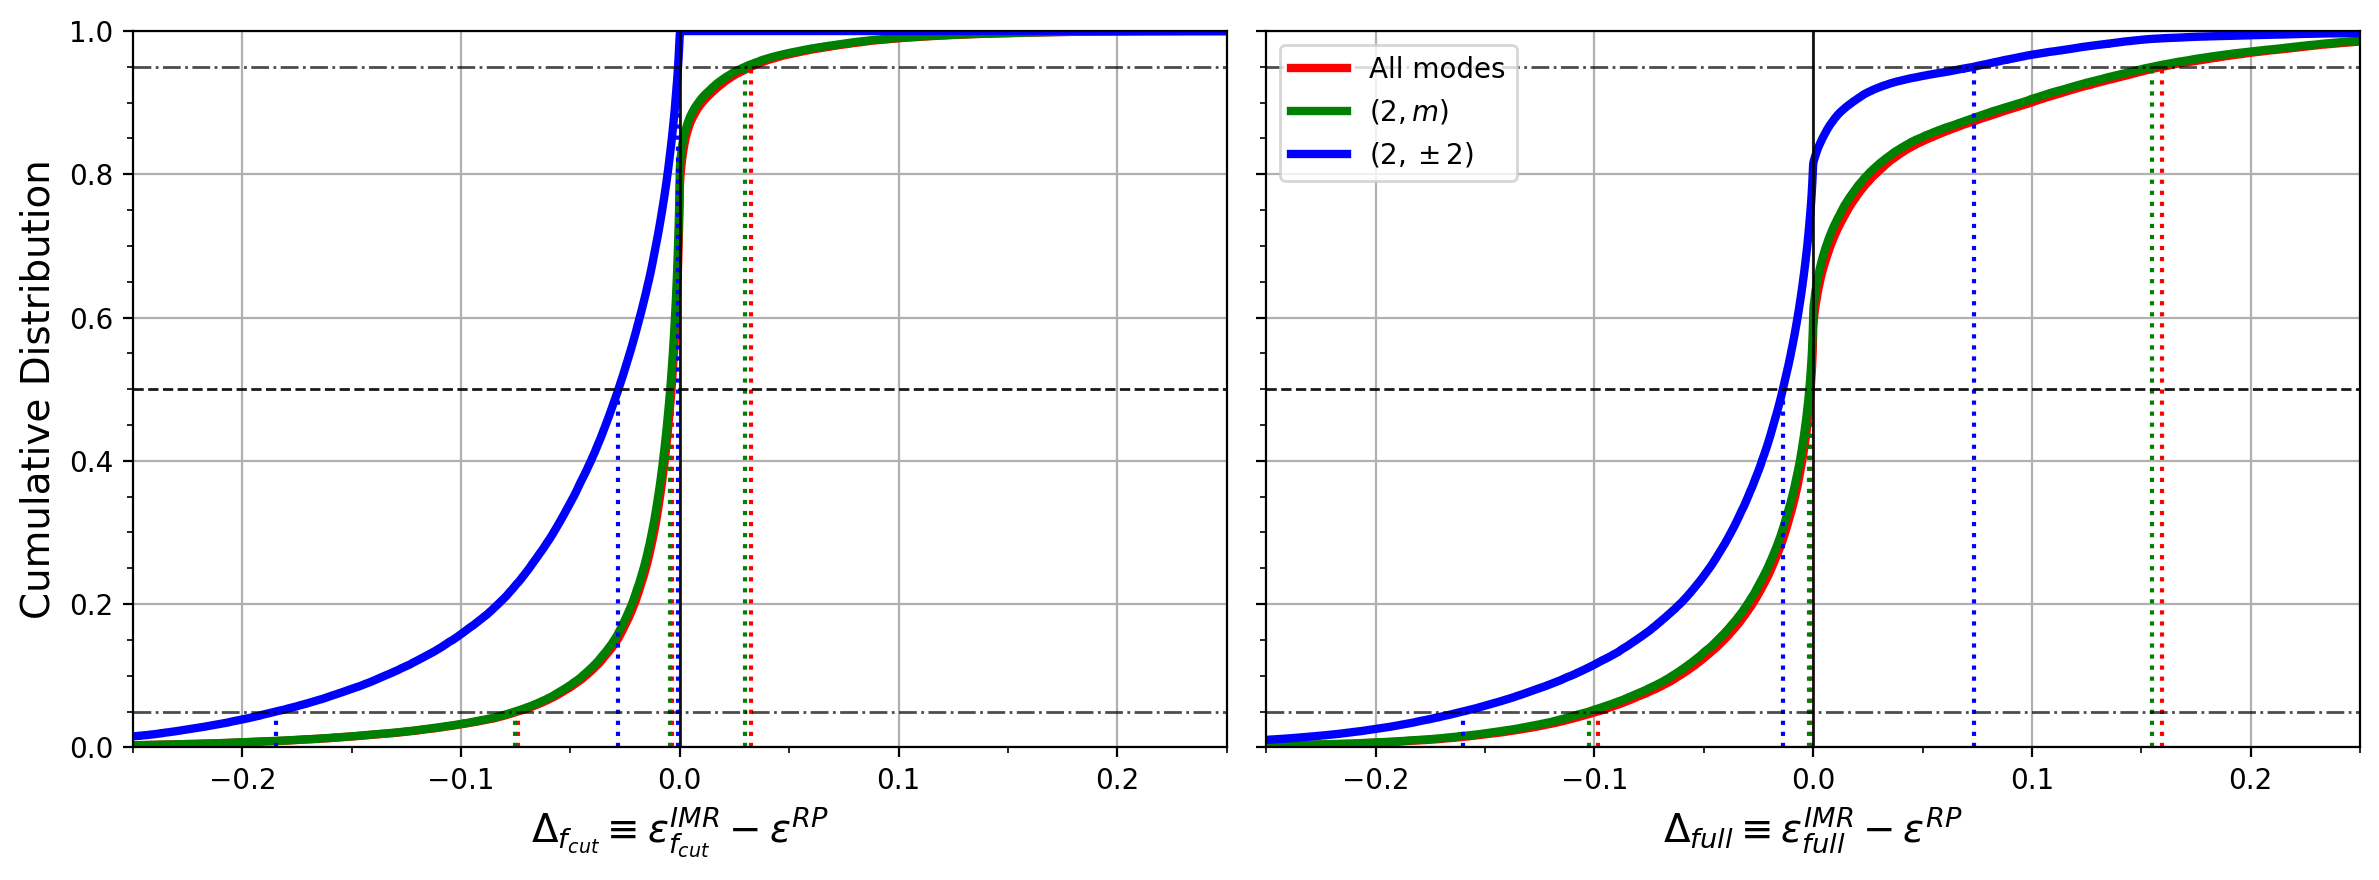

In [8]:
# Shared plot: 

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), dpi=200, sharey=True)

plot_cdf(ax[0], delta_all_cut, color="red",    label=r"All modes")
plot_cdf(ax[0], delta_2m_cut,  color="green", label=r"$(2, m)$")
plot_cdf(ax[0], delta_22_cut, color="blue",  label=r"$(2, \pm 2)$")

ax[0].axvline(0, color="k", linestyle="-", linewidth=1, alpha=0.9)
ax[0].axhline(0.5, color="k", linestyle="--", linewidth=1, alpha=0.9)
ax[0].axhline(0.05, color="k", linestyle="-.", linewidth=1, alpha=0.7)
ax[0].axhline(0.95, color="k", linestyle="-.", linewidth=1, alpha=0.7)


ax[0].set_xlabel(r"$\Delta_{f_{cut}} \equiv \epsilon^{IMR}_{f_{cut}} - \epsilon^{RP}$", fontsize=14)
ax[0].set_ylabel(r"Cumulative Distribution", fontsize=14)
ax[0].set_xlim(-0.25, 0.25)
ax[0].set_ylim(0, 1)
ax[0].grid(True)
ax[0].minorticks_on()
ax[0].xaxis.set_minor_locator(MultipleLocator(0.05))

plot_cdf(ax[1], delta_all_full, color="red",    label=r"All modes")
plot_cdf(ax[1], delta_2m_full,  color="green", label=r"$(2, m)$")
plot_cdf(ax[1], delta_22_full, color="blue",  label=r"$(2, \pm 2)$")

ax[1].axvline(0, color="k", linestyle="-", linewidth=1, alpha=0.9)
ax[1].axhline(0.5, color="k", linestyle="--", linewidth=1, alpha=0.9)
ax[1].axhline(0.05, color="k", linestyle="-.", linewidth=1, alpha=0.7)
ax[1].axhline(0.95, color="k", linestyle="-.", linewidth=1, alpha=0.7)

ax[1].legend(loc="upper left")

ax[1].set_xlabel(r"$\Delta_{full} \equiv \epsilon^{IMR}_{full} - \epsilon^{RP}$", fontsize=14)

ax[1].set_xlim(-0.25, 0.25)
ax[1].set_ylim(0, 1)
ax[1].grid(True)
ax[1].minorticks_on()
ax[1].xaxis.set_minor_locator(MultipleLocator(0.05))

plt.tight_layout()

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_CDF_fcut_n_full_m20_q1_s11_N105_all_2m_22.pdf', format='pdf', bbox_inches = 'tight')

In [9]:
from scipy.optimize import brentq

def get_precession_angles(theta_J, phi_J, theta_S, phi_S):
    """Compute cos/sin of i_JN and Omega_XH."""
    cos_theta_J = np.cos(theta_J)
    sin_theta_J = np.sin(theta_J)

    cos_i_JN = sin_theta_J * np.sin(theta_S) * np.cos(phi_J - phi_S) + cos_theta_J * np.cos(theta_S)
    sin_i_JN = np.sqrt(max(1 - cos_i_JN**2, 0.0))

    if sin_i_JN < 1e-12:
        cos_o_XH, sin_o_XH = 1.0, 0.0
    else:
        cos_o_XH = (np.cos(theta_S) * sin_theta_J * np.cos(phi_J - phi_S)
                    - np.sin(theta_S) * cos_theta_J) / sin_i_JN
        sin_o_XH = sin_theta_J * np.sin(phi_J - phi_S) / sin_i_JN

    return cos_i_JN, sin_i_JN, cos_o_XH, sin_o_XH

def get_Fp_for_nulls(theta_J, phi_J, theta_S, phi_S, psi=0.0):
    """Compute F+ for given sky/J directions with cos_i_JN = 0."""
    cos_i_JN, sin_i_JN, cos_o_XH, sin_o_XH = get_precession_angles(theta_J, phi_J, theta_S, phi_S)

    X_dot_l = (cos_i_JN * sin_o_XH * np.sin(phi_S)
               - cos_i_JN * cos_o_XH * np.cos(theta_S) * np.cos(phi_S)
               + sin_i_JN * np.sin(theta_S) * np.cos(phi_S))
    Y_dot_l = cos_o_XH * np.sin(phi_S) + sin_o_XH * np.cos(theta_S) * np.cos(phi_S)
    X_dot_m = (- cos_i_JN * sin_o_XH * np.cos(phi_S)
               - cos_i_JN * cos_o_XH * np.cos(theta_S) * np.sin(phi_S)
               + sin_i_JN * np.sin(theta_S) * np.sin(phi_S))
    Y_dot_m = - cos_o_XH * np.cos(phi_S) + sin_o_XH * np.cos(theta_S) * np.sin(phi_S)
    Z_dot_l = (- sin_i_JN * sin_o_XH * np.sin(phi_S)
               + sin_i_JN * cos_o_XH * np.cos(theta_S) * np.cos(phi_S)
               + cos_i_JN * np.sin(theta_S) * np.cos(phi_S))
    Z_dot_m = (sin_i_JN * sin_o_XH * np.cos(phi_S)
               + sin_i_JN * cos_o_XH * np.cos(theta_S) * np.sin(phi_S)
               + cos_i_JN * np.sin(theta_S) * np.sin(phi_S))

    P_dot_l = cos_i_JN * X_dot_l - sin_i_JN * Z_dot_l
    P_dot_m = cos_i_JN * X_dot_m - sin_i_JN * Z_dot_m
    Q_dot_l = Y_dot_l
    Q_dot_m = Y_dot_m

    Fp = 0.5 * (P_dot_l**2 - Q_dot_l**2 - P_dot_m**2 + Q_dot_m**2)
    return Fp


def theta_J_perp(phi_J, theta_S, phi_S):
    """
    Solve cos_i_JN = 0 for theta_J, given phi_J.
    sin(theta_J)*sin(theta_S)*cos(phi_J-phi_S) + cos(theta_J)*cos(theta_S) = 0
    => tan(theta_J) = -cos(theta_S) / (sin(theta_S)*cos(phi_J-phi_S))
    Returns theta_J in [0, pi].
    """
    denom = np.sin(theta_S) * np.cos(phi_J - phi_S)
    if abs(denom) < 1e-14:
        # cos(theta_J) must be 0 => theta_J = pi/2
        return np.pi / 2
    theta_J = np.arctan2(-np.cos(theta_S), denom)
    # arctan2 returns (-pi, pi]; map to [0, pi]
    if theta_J < 0:
        theta_J += np.pi
    return theta_J


def find_Fp_zero_perp(theta_S, phi_S, n_phi=100, psi=0.0):
    """
    Find all (theta_J, phi_J) where:
      1. (cos_i_JN = 0)
      2. F+ = 0

    Returns list of (theta_J, phi_J) solutions.
    """
    phi_J_arr = np.linspace(0, 2 * np.pi, n_phi, endpoint=False)

    # Evaluate F+ along the perpendicular locus
    Fp_locus = np.array([
        get_Fp_for_nulls(theta_J_perp(phi_J, theta_S, phi_S), phi_J, theta_S, phi_S, psi)
        for phi_J in phi_J_arr
    ])

    # Find sign changes → bracket zeros
    solutions = []
    for k in range(len(phi_J_arr) - 1):
        if Fp_locus[k] * Fp_locus[k + 1] < 0:
            phi_lo, phi_hi = phi_J_arr[k], phi_J_arr[k + 1]

            def f_optimize(phi_J):
                tJ = theta_J_perp(phi_J, theta_S, phi_S)
                return get_Fp_for_nulls(tJ, phi_J, theta_S, phi_S, psi)

            phi_sol = brentq(f_optimize, phi_lo, phi_hi, xtol=1e-12)
            theta_sol = theta_J_perp(phi_sol, theta_S, phi_S)
            solutions.append((theta_sol, phi_sol))

    return solutions, phi_J_arr, Fp_locus

def dist_from_plus_null(rp_params):
    """Compute distance in (theta_J, phi_J) from nearest F+ null on the cos_i_JN=0 locus."""
    theta_S = rp_params["theta_S"]
    phi_S   = rp_params["phi_S"]

    nulls, _, _ = find_Fp_zero_perp(theta_S, phi_S, n_phi=200)
    if not nulls:
        return np.inf  # No nulls found; treat as infinitely far

    theta_J = rp_params["theta_J"]
    phi_J   = rp_params["phi_J"]

    # Lets calculate J.J_null for each null and find the one with the largest J.J_null (smallest angle)
    max_dot = -np.inf
    for theta_null, phi_null in nulls:
        # Compute unit vector for current null
        J_null = np.array([
            np.sin(theta_null) * np.cos(phi_null),
            np.sin(theta_null) * np.sin(phi_null),
            np.cos(theta_null)
        ])

        # Compute unit vector for current rp_params
        J = np.array([
            np.sin(theta_J) * np.cos(phi_J),
            np.sin(theta_J) * np.sin(phi_J),
            np.cos(theta_J)
        ])

        dot_product = np.dot(J, J_null)
        if dot_product > max_dot:
            max_dot = dot_product
            
    # The angle between J and the nearest null is arccos(max_dot) - we return max_dot itself - the closer to 1, the closer to the null
    return max_dot

dist_from_plus_nulls_ensemble = [dist_from_plus_null(p) for p in rp_params_q1_chi1_1_chi2_1_z03_full]

dist_from_plus_nulls_ensemble = np.array(dist_from_plus_nulls_ensemble)

# Takes about 7 mins on Macbook Pro M1 without parallelization; can be sped up by parallelizing the loop over rp_params

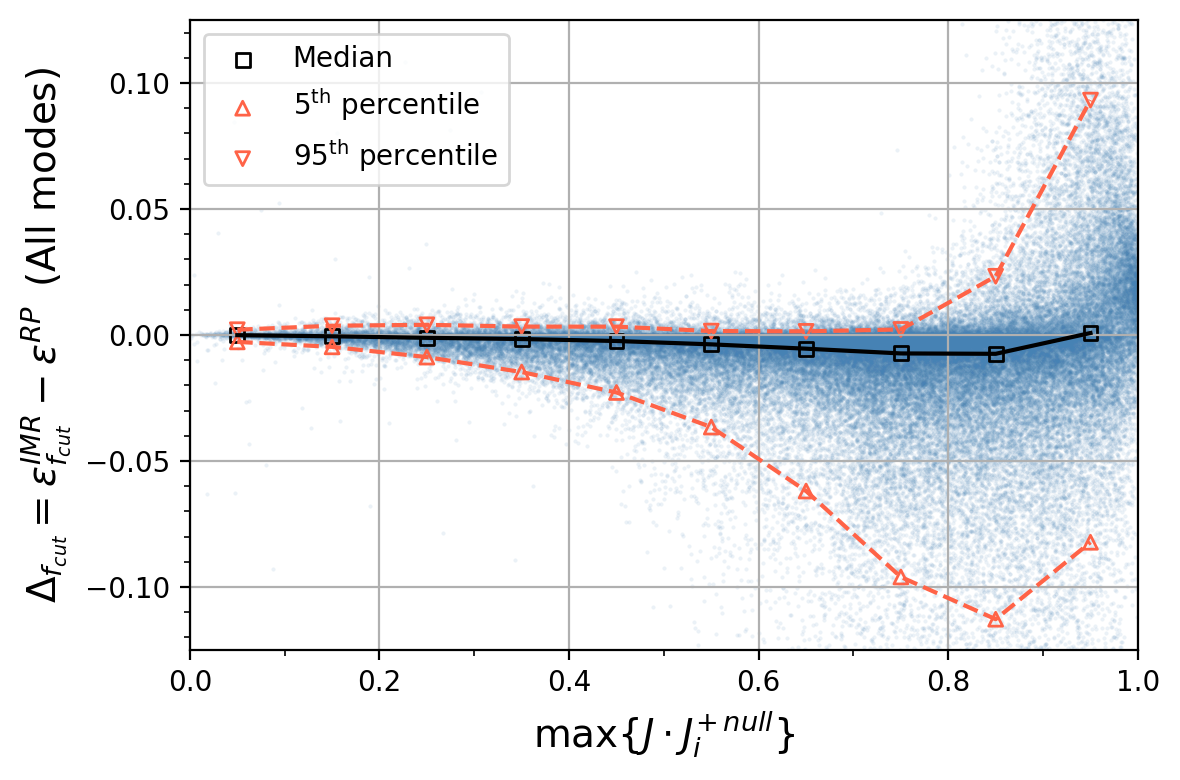

In [10]:
plt.figure(figsize=(6, 4), dpi=200)
bins_distance_from_null = np.linspace(0, 1, 11)
bin_centers_distance = 0.5 * (bins_distance_from_null[:-1] + bins_distance_from_null[1:])

delta_m20_q1_chi1_1_chi2_1_z03 = np.array(mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_cut) - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)

median_deltas = []
p5_deltas = []
p95_deltas = []
counts = []

for lo, hi in zip(bins_distance_from_null[:-1], bins_distance_from_null[1:]):
    mask = (dist_from_plus_nulls_ensemble >= lo) & (dist_from_plus_nulls_ensemble < hi)
    count = mask.sum()
    counts.append(count)
    if count > 0:
        median_delta = np.median(delta_m20_q1_chi1_1_chi2_1_z03[mask])
        p5_delta = np.percentile(delta_m20_q1_chi1_1_chi2_1_z03[mask], 5)
        p95_delta = np.percentile(delta_m20_q1_chi1_1_chi2_1_z03[mask], 95)

        median_deltas.append(median_delta)
        p5_deltas.append(p5_delta)
        p95_deltas.append(p95_delta)
    else:
        median_deltas.append(np.nan)
        p5_deltas.append(np.nan)
        p95_deltas.append(np.nan)

plt.scatter(dist_from_plus_nulls_ensemble, delta_m20_q1_chi1_1_chi2_1_z03, alpha=0.1, color="steelblue", s=0.25, rasterized=True)

plt.scatter(bin_centers_distance, median_deltas, label="Median", color="k", s=25, marker="s", facecolors="none")
plt.scatter(bin_centers_distance, p5_deltas, label=r"$5^{\rm th}$ percentile", color="tomato", s=25, marker="^", facecolors="none")
plt.scatter(bin_centers_distance, p95_deltas, label=r"$95^{\rm th}$ percentile", color="tomato", s=25, marker="v", facecolors="none")

plt.legend(loc="upper left")

plt.plot(bin_centers_distance, median_deltas, color="k")
plt.plot(bin_centers_distance, p5_deltas, color="tomato", linestyle="--")
plt.plot(bin_centers_distance, p95_deltas, color="tomato", linestyle="--")

plt.xlabel(r"$\max\{J \cdot J^{+\,null}_{i}\}$", fontsize=14)
plt.ylabel(r"$\Delta_{f_{cut}} = \epsilon^{IMR}_{f_{cut}} - \epsilon^{RP} \,$ (All modes)", fontsize=14)
plt.grid(True)
plt.ylim(-0.125, 0.125)
plt.xlim(0, 1)
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.1))
plt.tight_layout()

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_distance_from_plus_null_m20_q1_s11_N105_all_fcut.pdf', format='pdf', bbox_inches = 'tight')

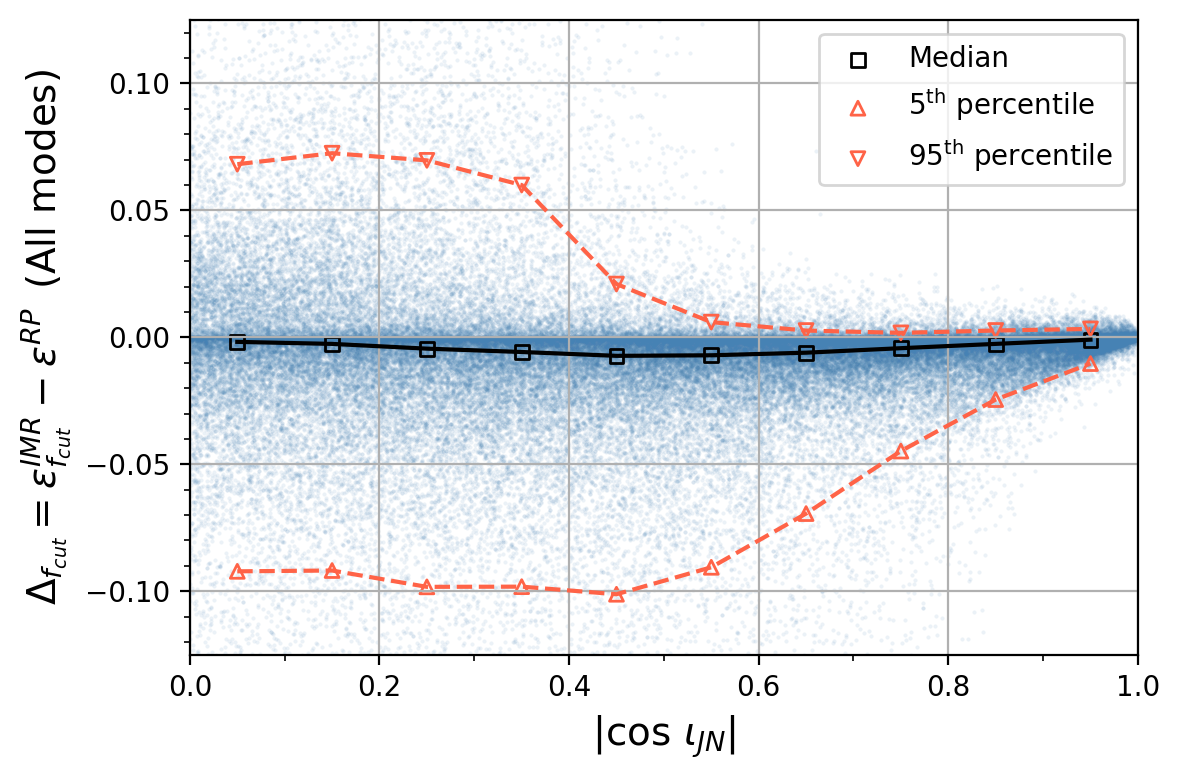

In [11]:
# cos_iJN_imrall_cut - we can use this to get the same plot as above but distributed by cos_iJN instead of distance from nulls
plt.figure(figsize=(6, 4), dpi=200)
bins_cos_i_JN = np.linspace(0, 1, 11)

bin_centers_cosi = 0.5 * (bins_cos_i_JN[:-1] + bins_cos_i_JN[1:])

abs_cos_iJN_imrall_cut = np.abs(cos_iJN_imrall_cut_chi1_1_chi2_1)

delta_m20_q1_chi1_1_chi2_1_z03 = np.array(mismatch_imrall_m20_q1_chi1_1_chi2_1_z03_cut) - np.array(mismatch_rp_m20_q1_chi1_1_chi2_1_z03)

median_deltas_cosi = []
p5_deltas_cosi = []
p95_deltas_cosi = []
counts_cosi = []

for lo, hi in zip(bins_cos_i_JN[:-1], bins_cos_i_JN[1:]):
    mask = (abs_cos_iJN_imrall_cut >= lo) & (abs_cos_iJN_imrall_cut < hi)
    count = mask.sum()
    counts_cosi.append(count)
    if count > 0:
        median_delta = np.median(delta_m20_q1_chi1_1_chi2_1_z03[mask])
        p5_delta = np.percentile(delta_m20_q1_chi1_1_chi2_1_z03[mask], 5)
        p95_delta = np.percentile(delta_m20_q1_chi1_1_chi2_1_z03[mask], 95)

        median_deltas_cosi.append(median_delta)
        p5_deltas_cosi.append(p5_delta)
        p95_deltas_cosi.append(p95_delta)
    else:
        median_deltas_cosi.append(np.nan)
        p5_deltas_cosi.append(np.nan)
        p95_deltas_cosi.append(np.nan)


plt.scatter(abs_cos_iJN_imrall_cut, delta_m20_q1_chi1_1_chi2_1_z03, alpha=0.1, color="steelblue", s=0.25, rasterized=True)

plt.scatter(bin_centers_cosi, median_deltas_cosi, label="Median", color="k", s=25, marker="s", facecolors="none")
plt.scatter(bin_centers_cosi, p5_deltas_cosi, label=r"$5^{\rm th}$ percentile", color="tomato", s=25, marker="^", facecolors="none")
plt.scatter(bin_centers_cosi, p95_deltas_cosi, label=r"$95^{\rm th}$ percentile", color="tomato", s=25, marker="v", facecolors="none")

plt.plot(bin_centers_cosi, median_deltas_cosi, color="k")
plt.plot(bin_centers_cosi, p5_deltas_cosi, color="tomato", linestyle="--")
plt.plot(bin_centers_cosi, p95_deltas_cosi, color="tomato", linestyle="--")
plt.legend(loc="upper right")

plt.xlabel(r"|$\cos\,\iota_{JN}$|", fontsize=14)
plt.ylabel(r"$\Delta_{f_{cut}} = \epsilon^{IMR}_{f_{cut}} - \epsilon^{RP} \,$ (All modes)", fontsize=14)
#plt.title(r"Mismatch difference vs $|\cos\,\iota_{JN}|$ (mcz=20, q=1, chi1=1, chi2=1, z=0.3)")

plt.grid(True)
plt.ylim(-0.125, 0.125)
plt.xlim(0, 1)
plt.minorticks_on()
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.1))
plt.tight_layout()

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_cosi_m20_q1_s11_N105_all_fcut.pdf', format='pdf', bbox_inches = 'tight')

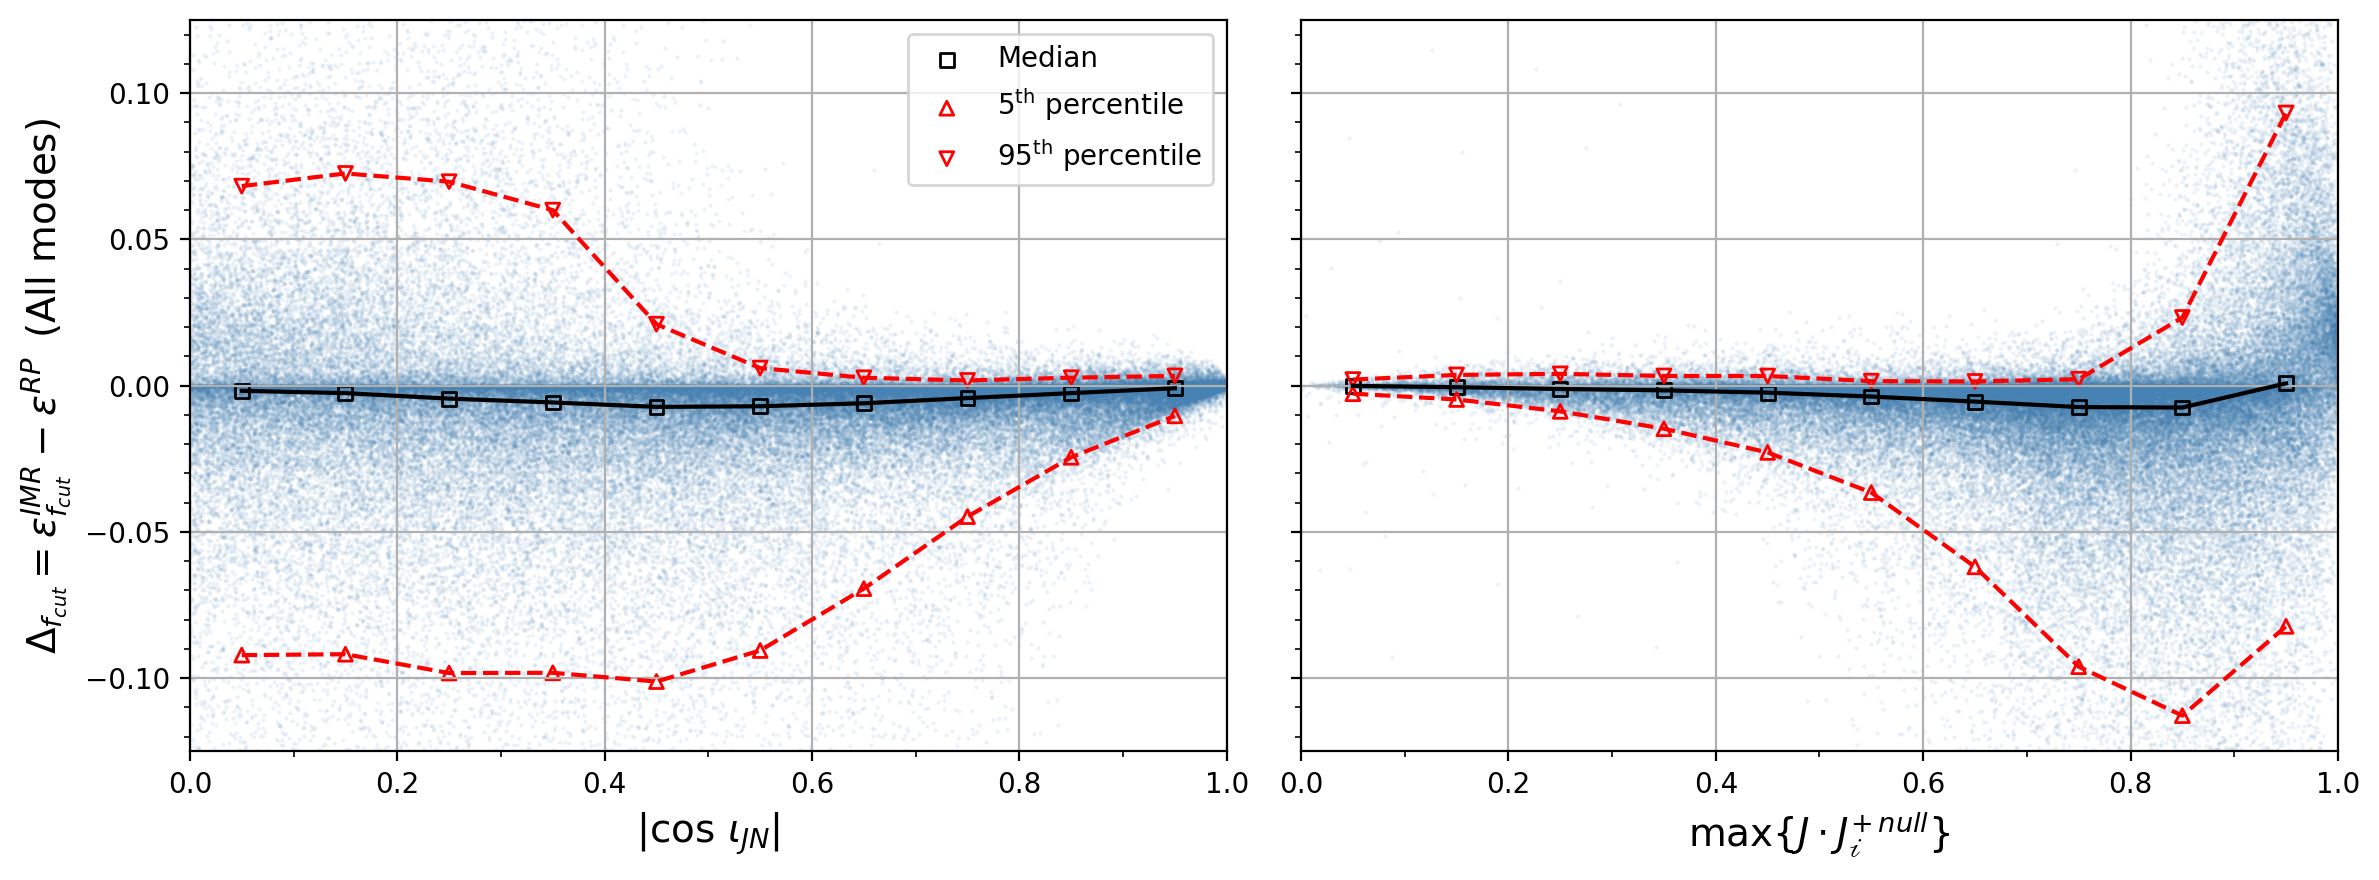

In [12]:
# Shared plot: cos_iJN vs distance from nulls

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), dpi=200, sharey=True)

ax[0].scatter(abs_cos_iJN_imrall_cut, delta_m20_q1_chi1_1_chi2_1_z03, alpha=0.1, color="steelblue", s=0.25, rasterized=True)

ax[0].scatter(bin_centers_cosi, median_deltas_cosi, label="Median", color="k", s=25, marker="s", facecolors="none")
ax[0].scatter(bin_centers_cosi, p5_deltas_cosi, label=r"$5^{\rm th}$ percentile", color="red", s=25, marker="^", facecolors="none")
ax[0].scatter(bin_centers_cosi, p95_deltas_cosi, label=r"$95^{\rm th}$ percentile", color="red", s=25, marker="v", facecolors="none")

ax[0].plot(bin_centers_cosi, median_deltas_cosi, color="k")
ax[0].plot(bin_centers_cosi, p5_deltas_cosi, color="red", linestyle="--")
ax[0].plot(bin_centers_cosi, p95_deltas_cosi, color="red", linestyle="--")

ax[0].legend(loc="upper right")

ax[0].set_xlabel(r"|$\cos\,\iota_{JN}$|", fontsize=14)
ax[0].set_ylabel(r"$\Delta_{f_{cut}} = \epsilon^{IMR}_{f_{cut}} - \epsilon^{RP} \,$ (All modes)", fontsize=14)
ax[0].set_xlim(0, 1)
ax[0].set_ylim(-0.125, 0.125)
ax[0].grid(True)
ax[0].minorticks_on()
ax[0].xaxis.set_minor_locator(MultipleLocator(0.1))

ax[1].scatter(dist_from_plus_nulls_ensemble, delta_m20_q1_chi1_1_chi2_1_z03, alpha=0.1, color="steelblue", s=0.25, rasterized=True)

ax[1].scatter(bin_centers_distance, median_deltas, label="Median", color="k", s=25, marker="s", facecolors="none")
ax[1].scatter(bin_centers_distance, p5_deltas, label=r"$5^{\rm th}$ percentile", color="red", s=25, marker="^", facecolors="none")
ax[1].scatter(bin_centers_distance, p95_deltas, label=r"$95^{\rm th}$ percentile", color="red", s=25, marker="v", facecolors="none")

ax[1].plot(bin_centers_distance, median_deltas, color="k")
ax[1].plot(bin_centers_distance, p5_deltas, color="red", linestyle="--")
ax[1].plot(bin_centers_distance, p95_deltas, color="red", linestyle="--")

ax[1].set_xlabel(r"$\max\{J \cdot J^{+\,null}_{\mathscr{i}}\}$", fontsize=14)
ax[1].set_xlim(0, 1)
ax[1].set_ylim(-0.125, 0.125)
ax[1].grid(True)
ax[1].minorticks_on()
ax[1].xaxis.set_minor_locator(MultipleLocator(0.1))

plt.tight_layout()

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_cosi_n_distance_from_plus_null_m20_q1_s11_N105_all_fcut.pdf', format='pdf', bbox_inches = 'tight')



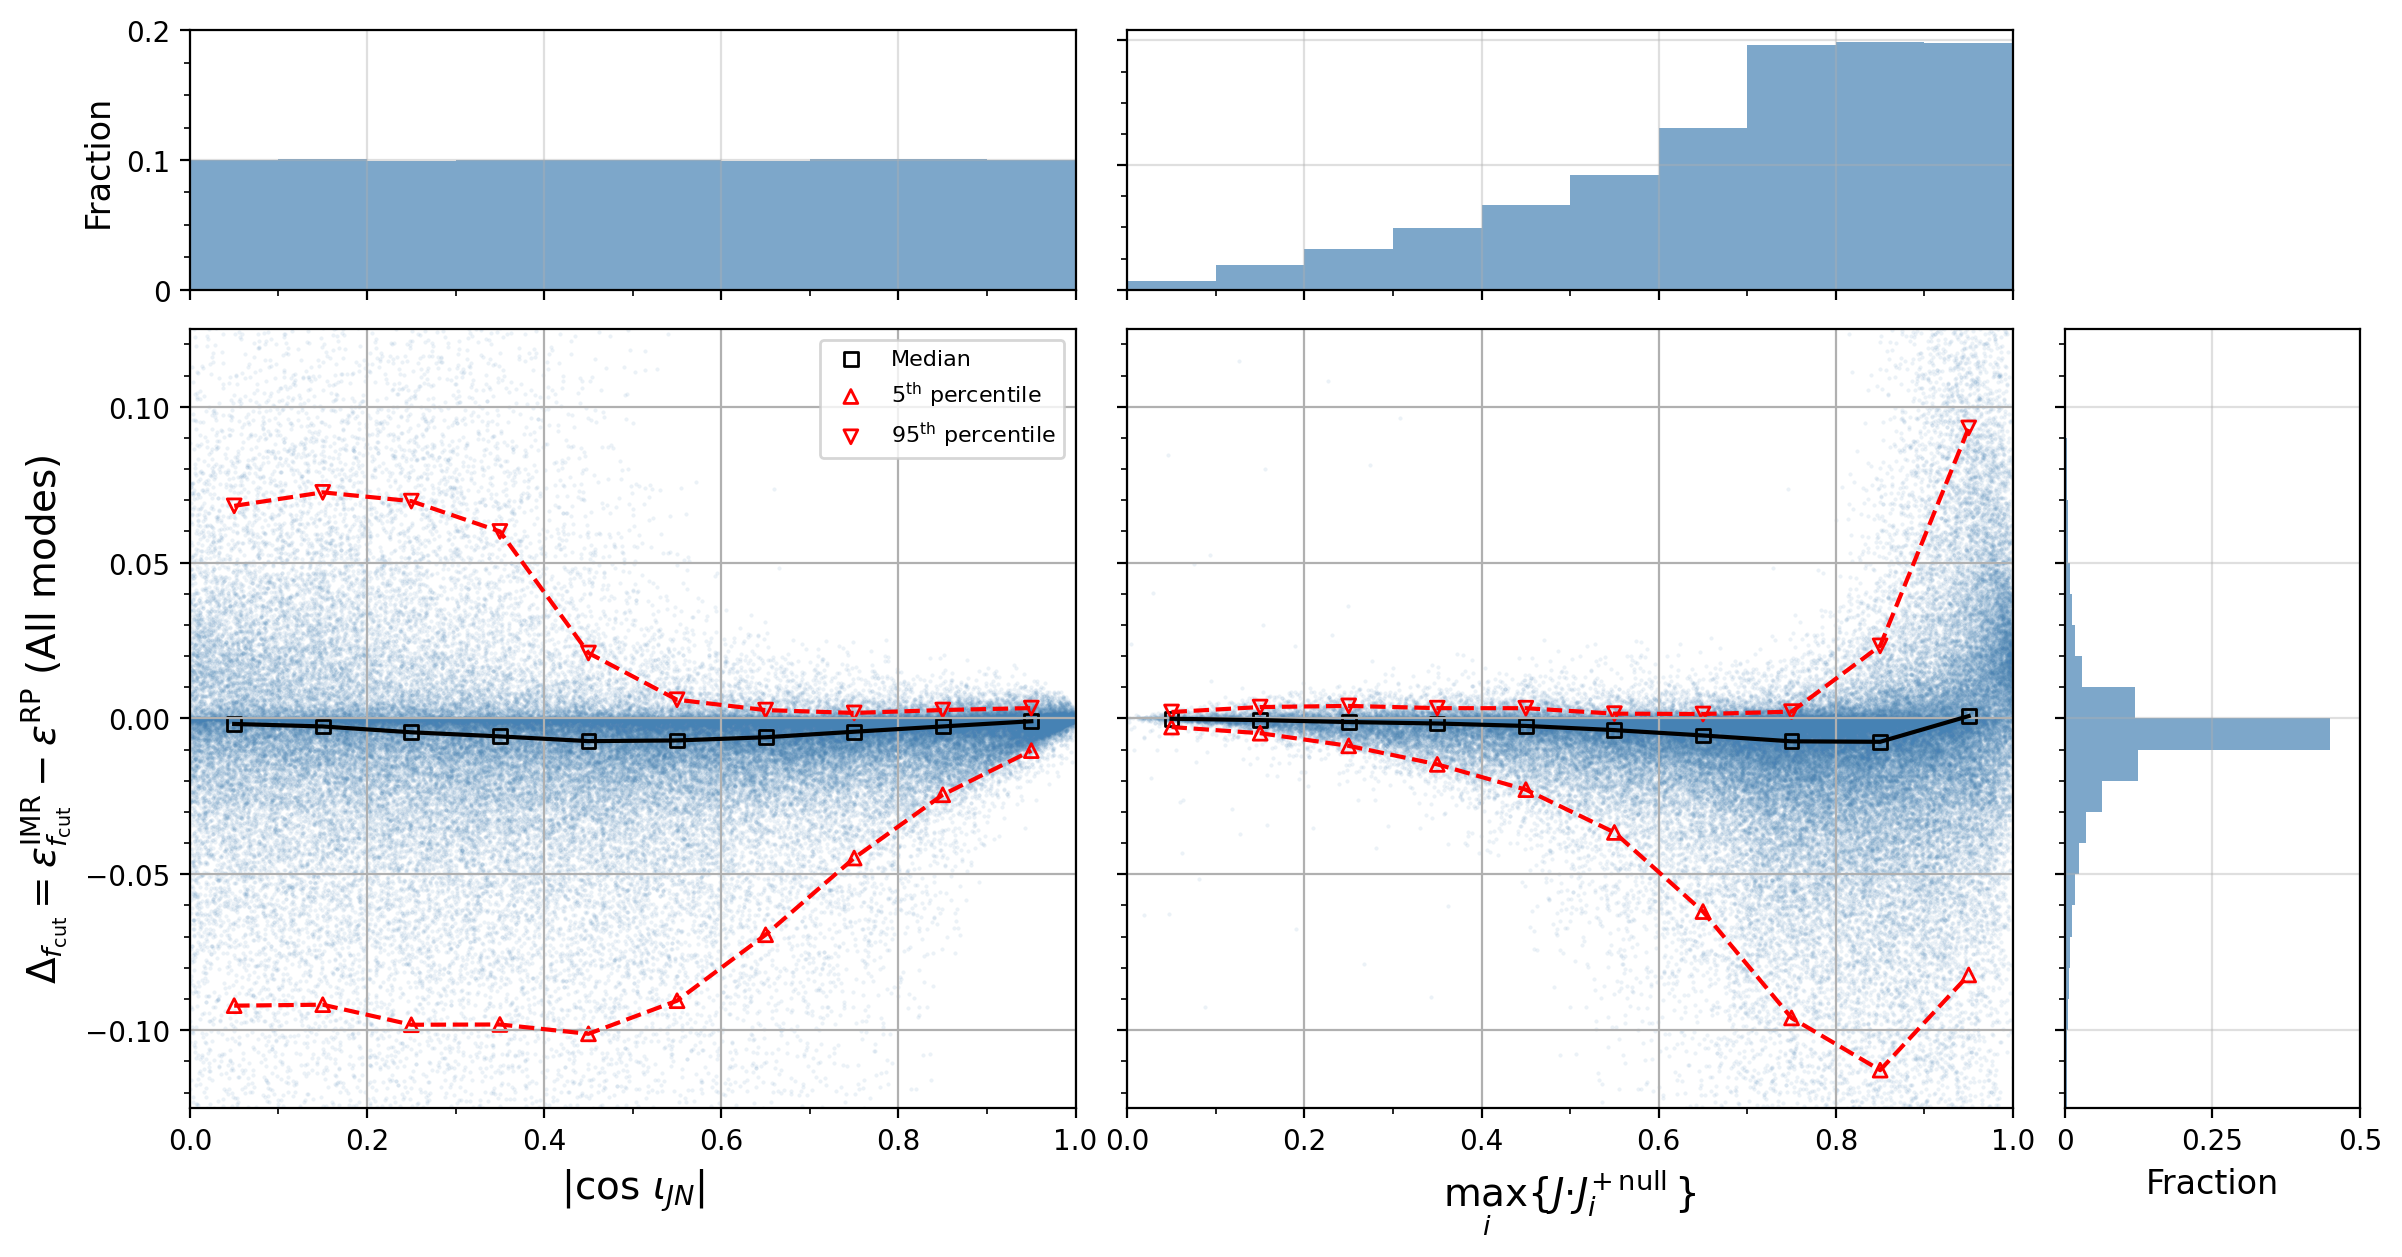

In [13]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 7), dpi=200)

gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[3, 3, 1],
    height_ratios=[1, 3],
    hspace=0.075,
    wspace=0.075,
)

ax_pdf_cosi = fig.add_subplot(gs[0, 0])
ax_pdf_dist = fig.add_subplot(gs[0, 1])
ax_empty = fig.add_subplot(gs[0, 2])


ax_scatter_cosi = fig.add_subplot(gs[1, 0], sharey=None)   

ax_scatter_dist = fig.add_subplot(gs[1, 1], sharey=ax_scatter_cosi)
ax_pdf_delta = fig.add_subplot(gs[1, 2])  


ax_pdf_cosi.sharex(ax_scatter_cosi)
ax_pdf_dist.sharex(ax_scatter_dist)


ax_pdf_cosi.hist(abs_cos_iJN_imrall_cut, bins=10, range=(0, 1),
                 color="steelblue", alpha=0.7)
ax_pdf_cosi.set_xlim(0, 1)
ax_pdf_cosi.set_ylabel("Fraction", fontsize=12)
ax_pdf_cosi.tick_params(labelleft=True, labelbottom=False)
ax_pdf_cosi.set_yticks([0, 0.1*len(abs_cos_iJN_imrall_cut), 0.2*len(abs_cos_iJN_imrall_cut)], labels=["0", "0.1", "0.2"])
ax_pdf_cosi.grid(True, alpha=0.4)
ax_pdf_cosi.minorticks_on()
ax_pdf_cosi.xaxis.set_minor_locator(MultipleLocator(0.1))


ax_pdf_dist.hist(dist_from_plus_nulls_ensemble, bins=10, range=(0, 1),
                 color="steelblue", alpha=0.7)
ax_pdf_dist.set_xlim(0, 1)
ax_pdf_dist.tick_params(labelleft=False, labelbottom=False)
ax_pdf_dist.set_yticks([0, 0.1*len(dist_from_plus_nulls_ensemble), 0.2*len(dist_from_plus_nulls_ensemble)])
ax_pdf_dist.grid(True, alpha=0.4)
ax_pdf_dist.minorticks_on()
ax_pdf_dist.xaxis.set_minor_locator(MultipleLocator(0.1))


ax_empty.axis("off")


ax_scatter_cosi.scatter(
    abs_cos_iJN_imrall_cut, delta_m20_q1_chi1_1_chi2_1_z03,
    alpha=0.1, color="steelblue", s=0.25, rasterized=True,
)
ax_scatter_cosi.scatter(bin_centers_cosi, median_deltas_cosi,
    label="Median", color="k", s=25, marker="s", facecolors="none")
ax_scatter_cosi.scatter(bin_centers_cosi, p5_deltas_cosi,
    label=r"$5^{\rm th}$ percentile", color="red", s=25, marker="^", facecolors="none")
ax_scatter_cosi.scatter(bin_centers_cosi, p95_deltas_cosi,
    label=r"$95^{\rm th}$ percentile", color="red", s=25, marker="v", facecolors="none")
ax_scatter_cosi.plot(bin_centers_cosi, median_deltas_cosi, color="k")
ax_scatter_cosi.plot(bin_centers_cosi, p5_deltas_cosi,  color="red", linestyle="--")
ax_scatter_cosi.plot(bin_centers_cosi, p95_deltas_cosi, color="red", linestyle="--")
ax_scatter_cosi.legend(loc="upper right", fontsize=8)
ax_scatter_cosi.set_xlabel(r"|$\cos\,\iota_{JN}$|", fontsize=14)
ax_scatter_cosi.set_ylabel(
    r"$\Delta_{f_{\rm cut}} = \epsilon^{\rm IMR}_{f_{\rm cut}} - \epsilon^{\rm RP}$ (All modes)",
    fontsize=14,
)
ax_scatter_cosi.set_xlim(0, 1)
ax_scatter_cosi.set_ylim(-0.125, 0.125)
ax_scatter_cosi.grid(True)
ax_scatter_cosi.minorticks_on()
ax_scatter_cosi.xaxis.set_minor_locator(MultipleLocator(0.1))


ax_scatter_dist.scatter(
    dist_from_plus_nulls_ensemble, delta_m20_q1_chi1_1_chi2_1_z03,
    alpha=0.1, color="steelblue", s=0.25, rasterized=True,
)
ax_scatter_dist.scatter(bin_centers_distance, median_deltas,
    label="Median", color="k", s=25, marker="s", facecolors="none")
ax_scatter_dist.scatter(bin_centers_distance, p5_deltas,
    label=r"$5^{\rm th}$ percentile", color="red", s=25, marker="^", facecolors="none")
ax_scatter_dist.scatter(bin_centers_distance, p95_deltas,
    label=r"$95^{\rm th}$ percentile", color="red", s=25, marker="v", facecolors="none")
ax_scatter_dist.plot(bin_centers_distance, median_deltas,  color="k")
ax_scatter_dist.plot(bin_centers_distance, p5_deltas,  color="red", linestyle="--")
ax_scatter_dist.plot(bin_centers_distance, p95_deltas, color="red", linestyle="--")
ax_scatter_dist.set_xlabel(r"$\max_{{i}}\{J \cdot J^{+\,\rm null}_{{i}}\}$", fontsize=14)
ax_scatter_dist.set_xlim(0, 1)
ax_scatter_dist.set_ylim(-0.125, 0.125)
ax_scatter_dist.grid(True)
ax_scatter_dist.minorticks_on()
ax_scatter_dist.xaxis.set_minor_locator(MultipleLocator(0.1))
ax_scatter_dist.tick_params(labelleft=False)



ax_pdf_delta.hist(delta_m20_q1_chi1_1_chi2_1_z03, bins=40, range=(-0.25, 0.15),
                 color="steelblue", alpha=0.7, orientation="horizontal")
ax_pdf_delta.sharey(ax_scatter_cosi)
ax_pdf_delta.set_ylim(-0.125, 0.125)
ax_pdf_delta.tick_params(labelleft=False, labelbottom=True)
ax_pdf_delta.set_xticks([0, 0.25 * len(delta_m20_q1_chi1_1_chi2_1_z03), 0.50*len(delta_m20_q1_chi1_1_chi2_1_z03)], labels=["0", "0.25", "0.5"])
ax_pdf_delta.set_xlabel("Fraction", fontsize=12)
ax_pdf_delta.grid(True, alpha=0.4)

fig = plt.gcf()
fig.savefig('figs/IMR_v_RP_cosi_n_distance_from_plus_null_with_marginals_m20_q1_s11_N105_all_fcut.pdf', format='pdf', bbox_inches = 'tight')

Integral of P(cos_theta) from 0 to 1: 0.9999999999336722


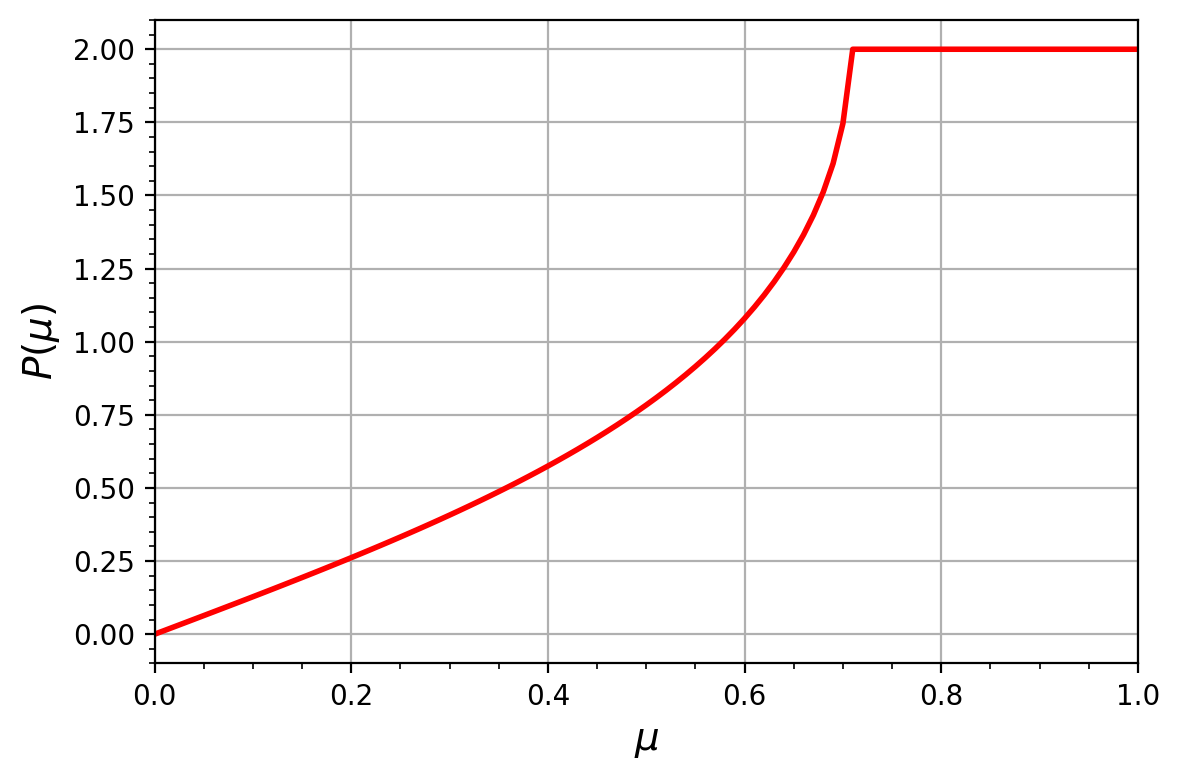

In [14]:
# Piecewise function for cos_theta
cos_theta_null = np.linspace(0, 1, 101)

P_cos_theta = np.zeros_like(cos_theta_null)

c = 2

for i, cos_theta in enumerate(cos_theta_null):
    if cos_theta > np.cos(np.pi/4):
        P_cos_theta[i] = c
    else:
        P_cos_theta[i] = c * (1 - (2/np.pi)*(np.arccos(cos_theta/(np.sqrt(1 - cos_theta**2)))))
        
        
# Calculating the normalization constant c such that the integral of P(cos_theta) from 0 to 1 equals 1
from scipy.integrate import quad

def integrand(cos_theta):
    if cos_theta > np.cos(np.pi/4):
        return c
    else:
        return c * (1 - (2/np.pi)*(np.arccos(cos_theta/(np.sqrt(1 - cos_theta**2)))))
    
integral, _ = quad(integrand, 0, 1)

print(f"Integral of P(cos_theta) from 0 to 1: {integral}")
        
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(cos_theta_null, P_cos_theta, color="red", linewidth=2)
plt.xlabel(r"$\mu$", fontsize=14)
plt.ylabel(r"$P(\mu)$", fontsize=14)
plt.grid(True)
plt.xlim(0, 1)
#plt.ylim(0, 2.5)

#plt.hist(dist_from_plus_nulls_ensemble, bins=10, range=(0, 1), color="steelblue", alpha=0.7)
#plt.yticks([0, 0.1*len(dist_from_plus_nulls_ensemble), 0.2*len(dist_from_plus_nulls_ensemble)], labels=["0", "1", "2"])
plt.minorticks_on()
plt.tight_layout()

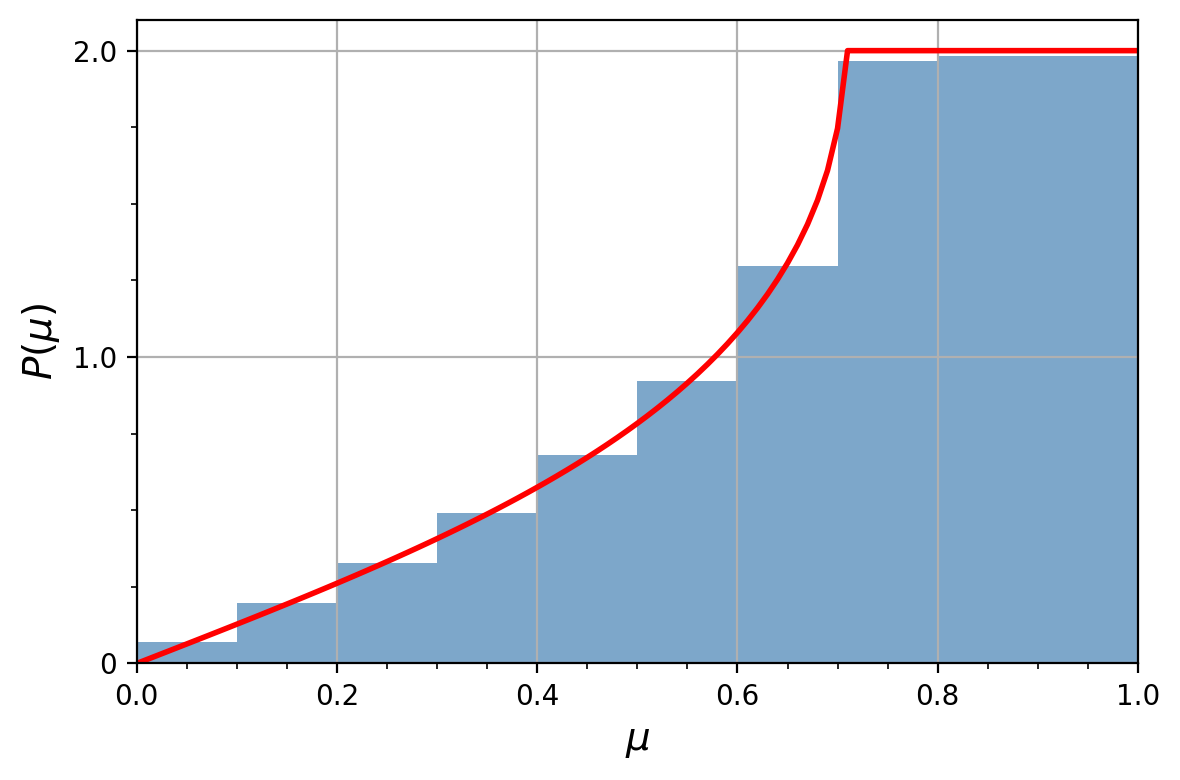

In [15]:
   
plt.figure(figsize=(6, 4), dpi=200)
plt.plot(cos_theta_null, P_cos_theta * 0.1 * len(dist_from_plus_nulls_ensemble), color="red", linewidth=2)
plt.xlabel(r"$\mu$", fontsize=14)
plt.ylabel(r"$P(\mu)$", fontsize=14)
plt.grid(True)
plt.xlim(0, 1)
#plt.ylim(0, 2.5)

plt.hist(dist_from_plus_nulls_ensemble, bins=10, range=(0, 1), color="steelblue", alpha=0.7)
plt.yticks([0, 0.1*len(dist_from_plus_nulls_ensemble), 0.2*len(dist_from_plus_nulls_ensemble)], labels=["0", "1.0", "2.0"])
plt.minorticks_on()
plt.tight_layout()